In [16]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
dataset=pd.read_csv("housing.csv")
x=dataset.iloc[ : ,:-1].values
y=dataset.iloc[ : , -1].values

In [18]:
print(x)

[[-122.23 37.88 41 ... 126 8.3252 'NEAR BAY']
 [-122.22 37.86 21 ... 1138 8.3014 'NEAR BAY']
 [-122.24 37.85 52 ... 177 7.2574 'NEAR BAY']
 ...
 [-121.22 39.43 17 ... 433 1.7 'INLAND']
 [-121.32 39.43 18 ... 349 1.8672 'INLAND']
 [-121.24 39.37 16 ... 530 2.3886 'INLAND']]


In [19]:
print(y)

[452600 358500 352100 ...  92300  84700  89400]


In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [21]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(missing_values=np.nan,strategy='mean')
imputer.fit(x_train[:,0:8])
x_train[:,0:8]=imputer.transform(x_train[:,0:8])  
imputer.fit(x_test[:,0:8])
x_test[:,0:8]=imputer.transform(x_test[:,0:8])  

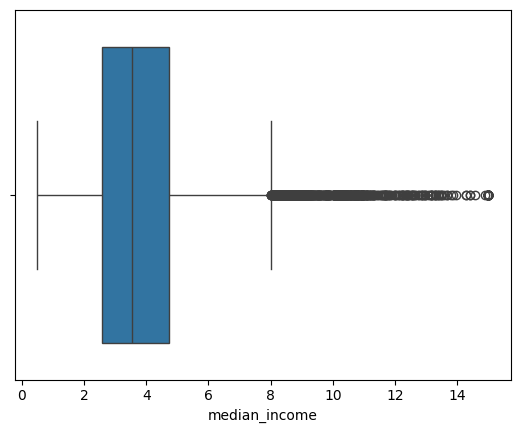

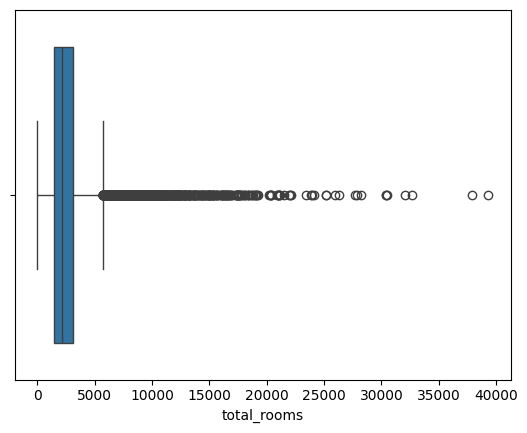

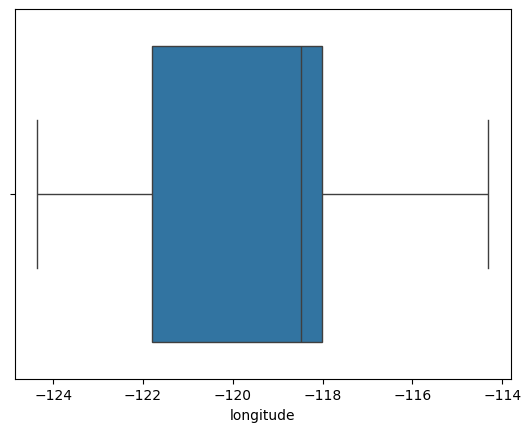

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
# outlier detect
sns.boxplot(x=dataset["median_income"])
plt.show()
sns.boxplot(x=dataset["total_rooms"])
plt.show()
sns.boxplot(x=dataset["longitude"])#isme nahi hai
plt.show()

In [23]:
# cols = dataset.iloc[ : ,2:8].values yai values deta hai sari
# for col in dataset.select_dtypes(include=['int64','float64']).columns: for all numeric col
cols = dataset.columns[2:8]
for col in cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dataset[col] = dataset[col].clip(lower, upper)
    

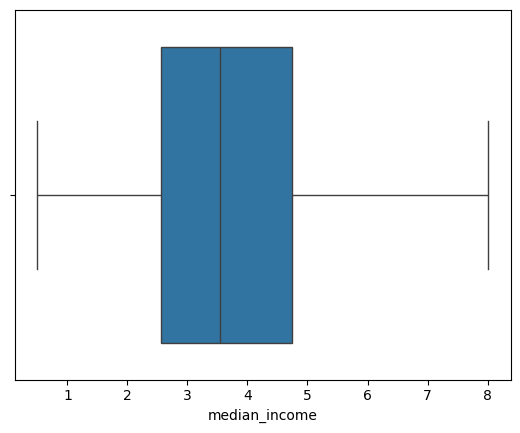

In [24]:
sns.boxplot(x=dataset["median_income"])
plt.show()

In [25]:
print(dataset.values[8])#9th row print hui

[-122.26 37.84 42 2555.0 665.0 1206 595.0 2.0804 'NEAR BAY' 226700]


In [26]:
from sklearn.compose import ColumnTransformer #yai negative value nahi leta
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[8])],remainder="passthrough")
x_train_ct=np.array(ct.fit_transform(x_train))#fit transform sparse matrix ban jata hai kabhi kabhi
x_test_ct=np.array(ct.fit_transform(x_test))

In [27]:
print(x.shape)

(20640, 9)


In [28]:
print(type(x))

<class 'numpy.ndarray'>


In [30]:
#decision Tree
from sklearn.tree import DecisionTreeRegressor
dec_regressor = DecisionTreeRegressor(random_state = 0)
dec_regressor.fit(x_train_ct, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [31]:
type(y_test)
# print(regressor.n_features_in_)model ko training ke time kitne features (columns) mile the

numpy.ndarray

In [32]:
y_pred_dec = dec_regressor.predict(x_test_ct)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_dec.reshape(len(y_pred_dec),1), y_test.reshape(len(y_test),1)),1))

[[139800. 136900.]
 [267600. 241300.]
 [160300. 200700.]
 ...
 [160900. 128600.]
 [200600. 259500.]
 [193600. 167600.]]


In [33]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_dec)

0.641897540466356

In [34]:
print(dec_regressor.n_features_in_)

13


In [35]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
ran_regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)
ran_regressor.fit(x_train_ct, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [36]:
y_pred_ran = ran_regressor.predict(x_test_ct)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_ran.reshape(len(y_pred_ran),1), y_test.reshape(len(y_test),1)),1))

[[142554. 136900.]
 [241544. 241300.]
 [140310. 200700.]
 ...
 [153421. 128600.]
 [227893. 259500.]
 [179037. 167600.]]


In [37]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_ran)

0.8223063115196496

In [38]:
print(x_train_ct.shape)#total row and col
print(y_train.shape)

(16512, 13)
(16512,)


In [39]:
print(ran_regressor.n_features_in_)#total feature

13


In [40]:
print(dataset.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')


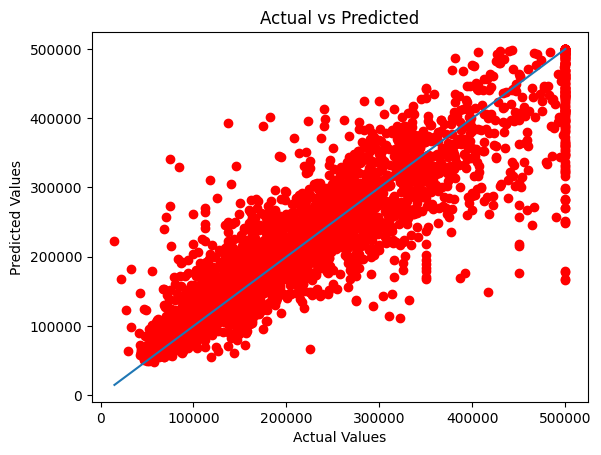

In [41]:
plt.figure()
plt.scatter(y_test, y_pred_ran, color="red")
min_val = min(min(y_test), min(y_pred_ran))#y_test ka smallest value y_pred ka smallest value Dono mein se jo sabse chhota hai → min_val
max_val = max(max(y_test), max(y_pred_ran))#min_val aur max_val use hote hain taaki perfect line poore data range ko cover kare

plt.plot([min_val, max_val], [min_val, max_val])#Ye exactly ek straight line banata hai:Actual = Predicted
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

In [42]:
# new data as a data frame
new_data = {
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41,
    'total_rooms': 880,
    'total_bedrooms': 129,
    'population': 322,
    'households': 126,
    'median_income': 8.3252,
    'ocean_proximity': 'NEAR BAY'
}

# dataframe
new_df = pd.DataFrame([new_data])

# same transformer apply for encoding
new_x = ct.transform(new_df)

# prediction
prediction = ran_regressor.predict(new_x)

print("Predicted House Price:", prediction[0])

Predicted House Price: 450621.13


C:\Users\mehak\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


In [43]:

# new data (same column order as training) as a array
new_data = [[
    -122.23,   # longitude
    37.88,     # latitude
    41,        # housing_median_age
    880,       # total_rooms
    129,       # total_bedrooms
    322,       # population
    126,       # households
    8.3252,    # median_income
    'NEAR BAY' # ocean_proximity
]]

# transformer apply
new_x = ct.transform(new_data)

# prediction
prediction = ran_regressor.predict(new_x)

print("Predicted House Price:", prediction[0])

Predicted House Price: 450621.13


In [44]:
#multiple linear regression
from sklearn.linear_model import LinearRegression
li_regressor=LinearRegression()
li_regressor.fit(x_train_ct,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred_li=li_regressor.predict(x_test_ct)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_li.reshape(len(y_pred_li),1),y_test.reshape(len(y_test),1)),1))

[[216580.61 136900.  ]
 [287452.26 241300.  ]
 [179457.69 200700.  ]
 ...
 [ 89138.77 128600.  ]
 [255304.59 259500.  ]
 [213286.6  167600.  ]]


In [46]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_li)

0.6381618075137216

In [47]:
#polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_reg = PolynomialFeatures(degree = 3)
x_poly = poly_reg.fit_transform(x_train_ct)
li_regressor2 = LinearRegression()
li_regressor2.fit(x_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
y_pred_poly = li_regressor2.predict(poly_reg.transform(x_test_ct))
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_poly.reshape(len(y_pred_poly),1), y_test.reshape(len(y_test),1)),1))

[[172287.6  136900.  ]
 [270341.69 241300.  ]
 [154723.12 200700.  ]
 ...
 [115517.11 128600.  ]
 [268251.47 259500.  ]
 [183556.46 167600.  ]]


In [49]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_poly)

0.6182321216126216

In [50]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
x_train_ct = sc_x.fit_transform(x_train_ct)
x_test_ct = sc_x.transform(x_test_ct)#Test data se kuch "seekhna" nahi hai Sirf training wale scale pe convert karna hai
y_train = sc_y.fit_transform(y_train.reshape(-1,1))

In [51]:
from sklearn.svm import SVR
svr_regressor = SVR(kernel = 'rbf')
svr_regressor.fit(x_train_ct, y_train)

C:\Users\mehak\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [52]:
y_pred_svr = sc_y.inverse_transform(svr_regressor.predict(x_test_ct).reshape(-1,1))
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_svr.reshape(len(y_pred_svr),1), y_test.reshape(len(y_test),1)),1))

[[131251.18 136900.  ]
 [260907.62 241300.  ]
 [150273.61 200700.  ]
 ...
 [121434.1  128600.  ]
 [260896.43 259500.  ]
 [188003.38 167600.  ]]


In [53]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_svr)

0.7563061547832209